# Exploratory Data Analysis - YouTube Spam Detection

This notebook performs a basic exploratory data analysis on the YouTube Spam Collection dataset.

It first uses the full interim dataset only for data-quality decisions that must happen before splitting. Then it uses only the train split for modeling-oriented EDA, so dev and test remain untouched until model selection and final evaluation.


## Setup


In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from spam_ham_detector.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR


sns.set_theme(style='whitegrid')


## Full Interim Data Quality

These checks support cleaning and split construction. They do not inspect model behavior or compare features for model design. Duplicate removal is intentionally exact: only comments with identical raw `CONTENT` are removed.


In [2]:
# Load the full interim dataset before splitting
interim_path = INTERIM_DATA_DIR / 'comments.csv'
interim_df = pd.read_csv(interim_path)

print('Full interim data loading report:')
print(f'- Rows loaded: {len(interim_df)}')
print(f'- Columns: {interim_df.columns.tolist()}')

interim_df.head()


Full interim data loading report:
- Rows loaded: 1956
- Columns: ['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS']


,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,1


In [3]:
# Schema and class balance before cleaning/splitting
print('Dataset shape:', interim_df.shape)
print('Columns:', interim_df.columns.tolist())

interim_df['CLASS'].value_counts().sort_index()


Dataset shape: (1956, 5)
Columns: ['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS']


CLASS
0     951
1    1005
Name: count, dtype: int64

In [4]:
# Malformed-row and missing-value checks on full interim data
malformed_mask = interim_df['CONTENT'].str.contains('\n', na=False)
quality_df = interim_df.loc[~malformed_mask].copy()

print('Full interim quality report:')
print(f'- Interim rows: {len(interim_df)}')
print(f'- Malformed rows removed before duplicate analysis: {malformed_mask.sum()}')
print(f'- Rows checked after malformed-row filter: {len(quality_df)}')

missing = quality_df.isnull().sum()
missing_pct = (missing / len(quality_df)) * 100
pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})


Full interim quality report:
- Interim rows: 1956
- Malformed rows removed before duplicate analysis: 1
- Rows checked after malformed-row filter: 1955


,Missing Count,Percentage
COMMENT_ID,0,0.000000
AUTHOR,0,0.000000
DATE,244,12.480818
CONTENT,0,0.000000
CLASS,0,0.000000


In [5]:
# Exact duplicate analysis on full interim data after malformed-row filtering
exact_content_duplicates = quality_df['CONTENT'].duplicated().sum()

print('Duplicate analysis:')
print(f'- Exact duplicate comments: {exact_content_duplicates}')
print('- No casing, punctuation, whitespace, accent, or semantic normalization is applied.')


Duplicate analysis:
- Exact duplicate comments: 196
- No casing, punctuation, whitespace, accent, or semantic normalization is applied.


In [6]:
# Examples of exact duplicate comments
exact_duplicate_examples = (
    quality_df[quality_df.duplicated('CONTENT', keep=False)]
    .sort_values('CONTENT')
    .groupby('CONTENT')
    .head(3)[['CONTENT', 'CLASS', 'AUTHOR']]
    .head(12)
)

exact_duplicate_examples


,CONTENT,CLASS,AUTHOR
1248,Check out my SEXY VIDEO :*,1,Adela Korman
1249,Check out my SEXY VIDEO :*,1,Adela Korman
1763,subscribe to my feed,1,real money
1245,subscribe to my feed,1,real money
1929,******* Facebook is LAME and so 2004! Check ou...,1,ricky swaggz
1910,******* Facebook is LAME and so 2004! Check ou...,1,ricky swaggz
1946,**CHECK OUT MY NEW MIXTAPE**** **CHECK OUT MY ...,1,ThirdDegr3e
1945,**CHECK OUT MY NEW MIXTAPE**** **CHECK OUT MY ...,1,ThirdDegr3e
1947,**CHECK OUT MY NEW MIXTAPE**** **CHECK OUT MY ...,1,ThirdDegr3e
1821,:),0,ben mashall


## Train-Only Exploratory Analysis

It uses only the train split to describe class patterns, text features, authors, time patterns, and word content that can influence modeling decisions.


In [7]:
# Load the train split for modeling-oriented EDA
train_path = PROCESSED_DATA_DIR / 'train.csv'
train_df = pd.read_csv(train_path)
train_original_columns = train_df.columns.tolist()

print('Train split loading report:')
print(f'- Rows loaded: {len(train_df)}')
print(f'- Columns: {train_df.columns.tolist()}')

train_df.head()


Train split loading report:
- Rows loaded: 1055
- Columns: ['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS']


,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,LneaDw26bFv3qdtt-_26444mTK_vLq39DRUsyxXMKkQ,AD OSG,NaN,Please check out my New Song (MUSIC VIDEO) AD ...,1
1,z131i14binnjjtrnn224e5yw5re0jxtmf,emrah England,2015-05-19T22:10:02.515000,Take a look at this video on YouTube:﻿,1
2,z13rj3tohue0exbkz22iyr3w2rntsfqcm,jameel alnozha,2015-05-25T06:01:01.050000,amazing song﻿,0
3,z12etvywgsjpthpvz22gwfm4vnqyydj3l,Rebecca Shields,2014-10-19T13:59:50,Yesterday this video have 1 million likes and ...,0
4,z13ez3wxdsnjv1dej22uedkr2vbsgj2m3,Chris Madzier,2014-10-29T01:23:19,Katy Perry - Roar (Official) #soundsofsunday ...,0


### Train Dataset Overview


In [8]:
# Basic train-split statistics
print('Train dataset shape:', train_df.shape)
print('Column names:', train_df.columns.tolist())

train_df['CLASS'].value_counts().sort_index()


Train dataset shape: (1055, 5)
Column names: ['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS']


CLASS
0    551
1    504
Name: count, dtype: int64

### Target Variable Analysis

#### Class distribution


In [9]:
# Class distribution
class_counts = train_df['CLASS'].value_counts()
class_pct = train_df['CLASS'].value_counts(normalize=True) * 100

pd.DataFrame({'Count': class_counts, 'Percentage': class_pct})

,Count,Percentage
CLASS,,
0,551,52.227488
1,504,47.772512


### Feature Engineering


#### Text Features


In [10]:
# Create text-based features
train_df['text_length'] = train_df['CONTENT'].str.len()
train_df['word_count'] = train_df['CONTENT'].str.split().str.len()

train_df[['CONTENT', 'text_length', 'word_count']].head()

,CONTENT,text_length,word_count
0,Please check out my New Song (MUSIC VIDEO) AD ...,57,12
1,Take a look at this video on YouTube:﻿,38,8
2,amazing song﻿,13,2
3,Yesterday this video have 1 million likes and ...,67,13
4,Katy Perry - Roar (Official) #soundsofsunday ...,57,8


#### Statistical Comparison by Class


In [11]:
# Compare text features between spam and ham
stats_by_class = train_df.groupby('CLASS')[['text_length', 'word_count']].agg(['mean', 'median', 'std'])

stats_by_class.index = stats_by_class.index.map({0: 'Ham', 1: 'Spam'})
stats_by_class.round(2)

text_length                word_count              
             mean median     std       mean median    std
CLASS                                                    
Ham         50.13   34.0   51.03       9.28    6.0   9.59
Spam       143.11   78.0  146.92      22.75   12.0  26.48

In [12]:
# Percentile Analysis - Text Length
print('Percentile Analysis - Text Length:')
for idx, cls_name in [(0, 'Ham'), (1, 'Spam')]:
    data = train_df[train_df['CLASS'] == idx]['text_length']
    print(f'{cls_name}:')
    print(f'  25th percentile: {data.quantile(0.25)}')
    print(f'  50th percentile: {data.quantile(0.50)}')
    print(f'  75th percentile: {data.quantile(0.75)}')
    print(f'  Maximum: {data.max()}')
    print()

# Show examples of extreme values
print('Extreme Length Examples:')
extreme_spam = train_df[(train_df['CLASS'] == 1) & (train_df['text_length'] > train_df[train_df['CLASS']==1]['text_length'].quantile(0.99))]
print(f'Top 1% longest spam comments: {len(extreme_spam)} examples')
print(f'Length range: {extreme_spam["text_length"].min()} - {extreme_spam["text_length"].max()} characters')

Percentile Analysis - Text Length:
Ham:
  25th percentile: 18.0
  50th percentile: 34.0
  75th percentile: 65.0
  Maximum: 520

Spam:
  25th percentile: 46.75
  50th percentile: 78.0
  75th percentile: 192.25
  Maximum: 1078

Extreme Length Examples:
Top 1% longest spam comments: 6 examples
Length range: 575 - 1078 characters


#### Visualizations


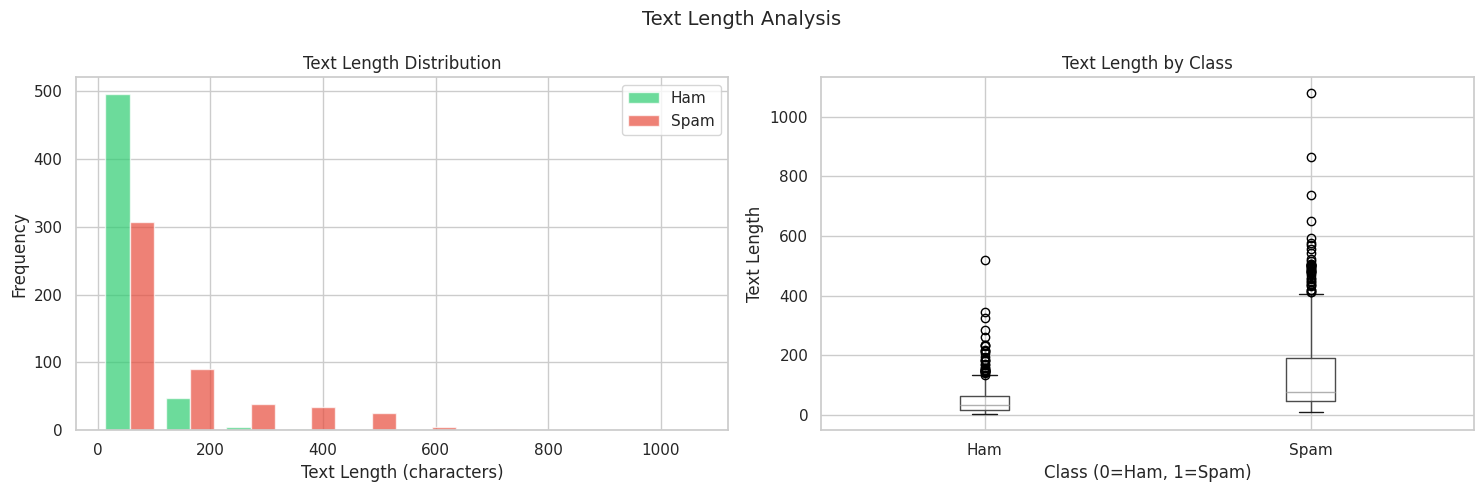

In [13]:
# Text length analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution
axes[0].hist(
    [train_df[train_df['CLASS'] == 0]['text_length'], train_df[train_df['CLASS'] == 1]['text_length']],
    label=['Ham', 'Spam'],
    color=['#2ecc71', '#e74c3c'],
    alpha=0.7,
)
axes[0].set_title('Text Length Distribution')
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
train_df.boxplot(column='text_length', by='CLASS', ax=axes[1])
axes[1].set_title('Text Length by Class')
axes[1].set_xlabel('Class (0=Ham, 1=Spam)')
axes[1].set_ylabel('Text Length')
plt.sca(axes[1])
plt.xticks([1, 2], ['Ham', 'Spam'])

fig.suptitle('Text Length Analysis', fontsize=14)

plt.tight_layout()
plt.show()

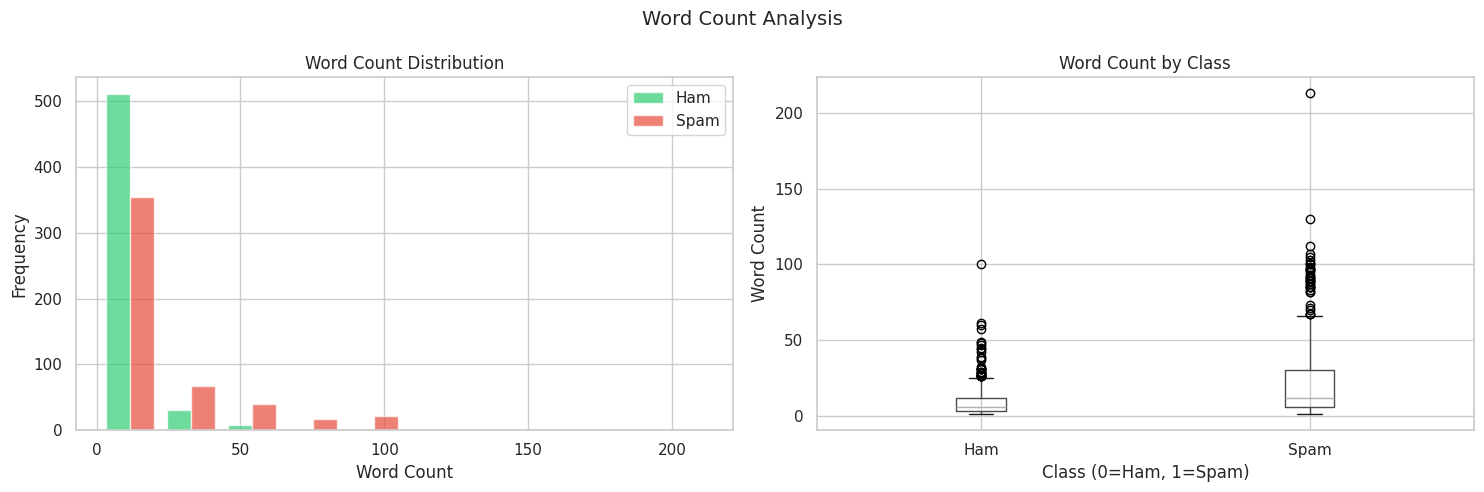

In [14]:
# Word count analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution
axes[0].hist(
    [train_df[train_df['CLASS'] == 0]['word_count'], train_df[train_df['CLASS'] == 1]['word_count']],
    label=['Ham', 'Spam'],
    color=['#2ecc71', '#e74c3c'],
    alpha=0.7,
)
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
train_df.boxplot(column='word_count', by='CLASS', ax=axes[1])
axes[1].set_title('Word Count by Class')
axes[1].set_xlabel('Class (0=Ham, 1=Spam)')
axes[1].set_ylabel('Word Count')
plt.sca(axes[1])
plt.xticks([1, 2], ['Ham', 'Spam'])

fig.suptitle('Word Count Analysis', fontsize=14)

plt.tight_layout()
plt.show()

### Temporal Analysis


#### Date Parsing and Feature Extraction


In [15]:
# Temporal Analysis Coverage
print('Temporal Analysis Coverage:')
print(f'- Total records: {len(train_df)}')
print(f'- Records with dates: {train_df["DATE"].notna().sum()}')
print(f'- Missing dates: {train_df["DATE"].isna().sum()} ({(train_df["DATE"].isna().sum()/len(train_df))*100:.1f}%)')
print(f'- Temporal patterns based on {train_df["DATE"].notna().sum()} records')

Temporal Analysis Coverage:
- Total records: 1055
- Records with dates: 936
- Missing dates: 119 (11.3%)
- Temporal patterns based on 936 records


In [16]:
# Convert DATE to datetime
train_df['DATE'] = pd.to_datetime(train_df['DATE'], format='ISO8601', errors='coerce')
train_df['date_only'] = train_df['DATE'].dt.date
train_df['hour'] = train_df['DATE'].dt.hour
train_df['day_of_week'] = train_df['DATE'].dt.day_name()

print('Date Range:')
print(f'From: {train_df["DATE"].min()}')
print(f'To: {train_df["DATE"].max()}')
print(f'Duration: {(train_df["DATE"].max() - train_df["DATE"].min()).days} days')

# Check for any parsing errors
null_dates = train_df['DATE'].isnull().sum()
if null_dates > 0:
    print()
    print(f'Warning: {null_dates} dates could not be parsed')

Date Range:
From: 2013-07-12 22:33:27.916000
To: 2015-06-05 20:01:23
Duration: 692 days



#### Temporal Patterns


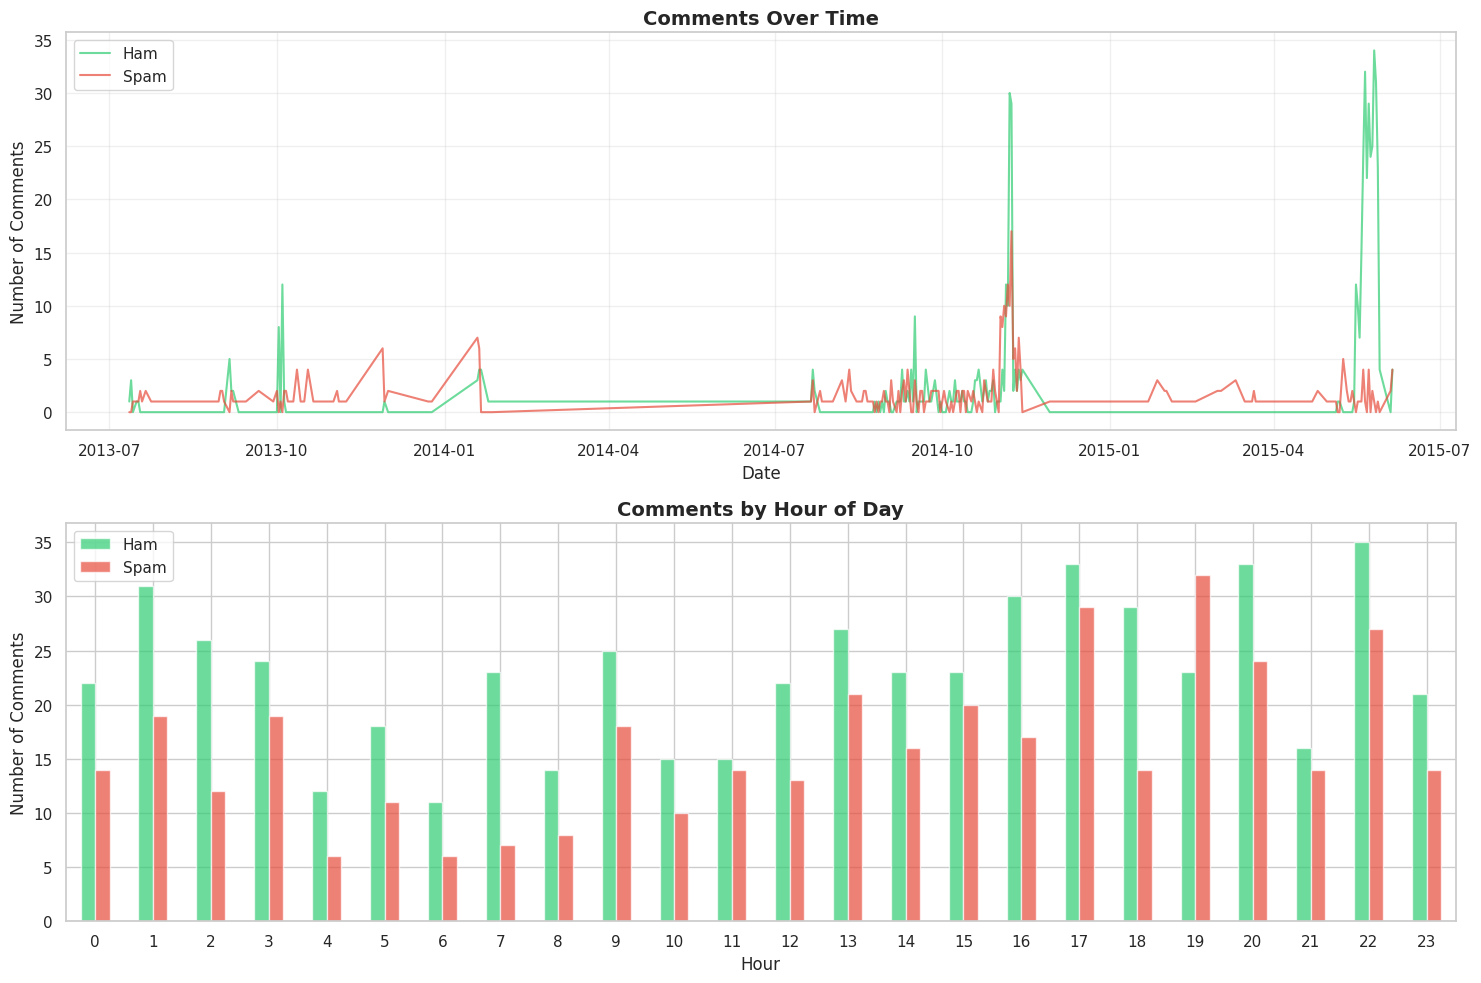

In [17]:
# Comments over time
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Comments by date
comments_by_date = train_df.groupby(['date_only', 'CLASS']).size().unstack(fill_value=0)
comments_by_date.plot(ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0].set_title('Comments Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Comments')
axes[0].legend(['Ham', 'Spam'])
axes[0].grid(True, alpha=0.3)

# Comments by hour
comments_by_hour = train_df.groupby(['hour', 'CLASS']).size().unstack(fill_value=0)
comments_by_hour.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[1].set_title('Comments by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Number of Comments')
axes[1].legend(['Ham', 'Spam'])
axes[1].set_xticklabels(range(24), rotation=0)

plt.tight_layout()
plt.show()

### Author Analysis

#### Author Statistics


In [18]:
# Top authors
print('Total unique authors:', train_df['AUTHOR'].nunique())
print()

print('Top 10 Most Active Authors:')
train_df['AUTHOR'].value_counts().head(10)

Total unique authors: 1013

Top 10 Most Active Authors:


AUTHOR
Louis Bryant        5
RapStarz Coleman    4
Derek Moya          4
M.E.S               3
KOZZI RAP           3
LuckyMusiqLive      3
D Maw               2
101Tele             2
Laura Brown         2
Amir bassem         2
Name: count, dtype: int64

#### Top Authors by Class


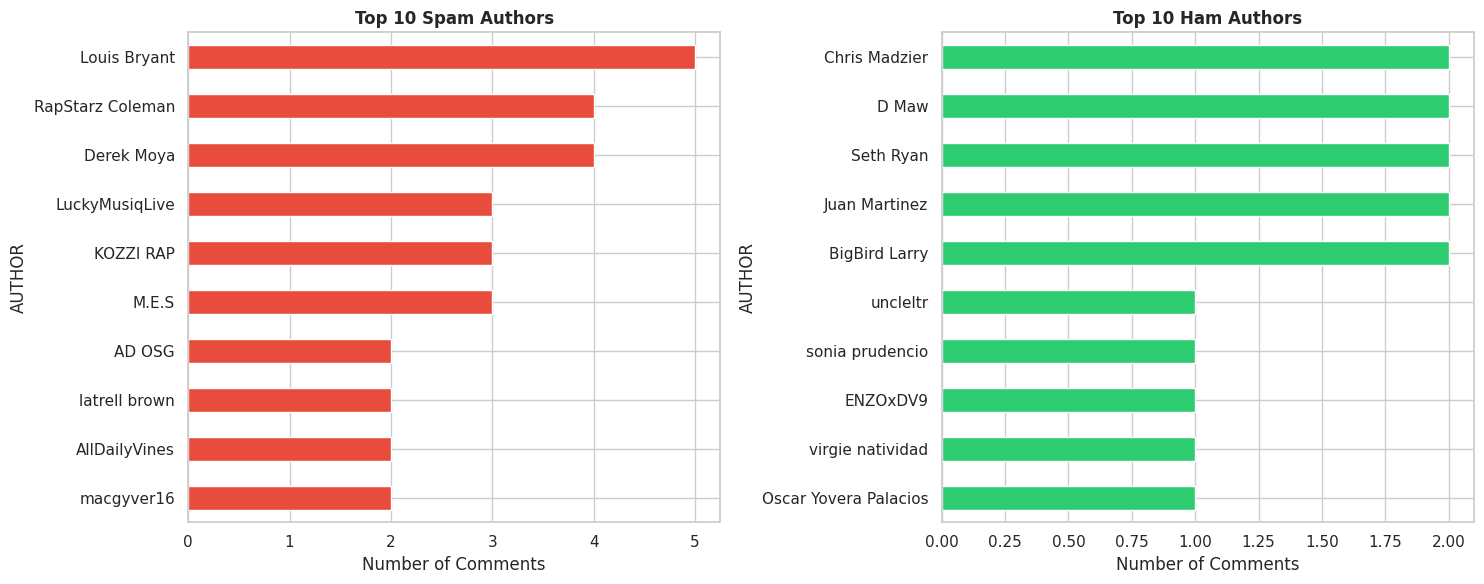

In [19]:
# Authors by class
spam_authors = train_df[train_df['CLASS'] == 1]['AUTHOR'].value_counts().head(10)
ham_authors = train_df[train_df['CLASS'] == 0]['AUTHOR'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

spam_authors.plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top 10 Spam Authors', fontweight='bold')
axes[0].set_xlabel('Number of Comments')
axes[0].invert_yaxis()

ham_authors.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top 10 Ham Authors', fontweight='bold')
axes[1].set_xlabel('Number of Comments')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Text Content Analysis


#### Common Words


In [20]:
def get_top_words(texts, n=20, min_length=3):
    """Extract top n most common words from texts"""
    # Combine all texts
    all_text = ' '.join(texts.astype(str))
    # Convert to lowercase and extract words
    words = re.findall(r'\b[a-z]+\b', all_text.lower())
    # Filter by length
    words = [w for w in words if len(w) >= min_length]
    # Count and return top n
    return Counter(words).most_common(n)

In [21]:
# Get top words for spam comments
spam_words = get_top_words(train_df[train_df['CLASS'] == 1]['CONTENT'], n=20)

print('Top 20 Words in SPAM Comments:')
for word, count in spam_words:
    print(f'{word:20s} {count:5d}')

Top 20 Words in SPAM Comments:
and                    279
you                    278
the                    266
out                    222
check                  216
com                    182
this                   171
please                 132
subscribe              125
for                    111
channel                 94
like                    94
http                    81
video                   78
https                   74
can                     73
www                     72
youtube                 70
guys                    66
just                    63


In [22]:
# Get top words for ham comments
ham_words = get_top_words(train_df[train_df['CLASS'] == 0]['CONTENT'], n=20)

print('\nTop 20 Words in HAM Comments:')
for word, count in ham_words:
    print(f'{word:20s} {count:5d}')


Top 20 Words in HAM Comments:
this                   173
the                    172
song                   120
love                    83
and                     80
you                     77
video                   58
like                    55
views                   51
that                    49
she                     38
katy                    37
for                     30
but                     30
good                    30
perry                   29
best                    29
billion                 28
are                     27
music                   24


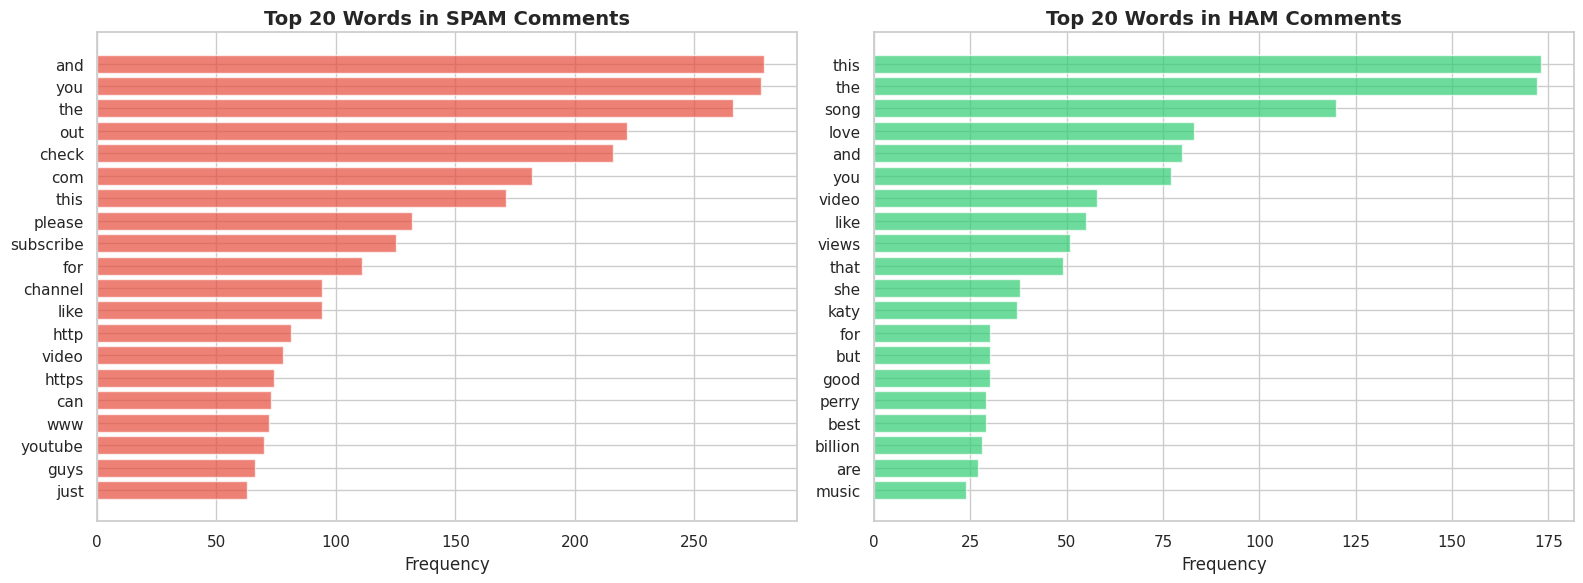

In [23]:
# Visualize top words
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Spam words
spam_df = pd.DataFrame(spam_words, columns=['word', 'count'])
axes[0].barh(spam_df['word'], spam_df['count'], color='#e74c3c', alpha=0.7)
axes[0].set_title('Top 20 Words in SPAM Comments', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Ham words
ham_df = pd.DataFrame(ham_words, columns=['word', 'count'])
axes[1].barh(ham_df['word'], ham_df['count'], color='#2ecc71', alpha=0.7)
axes[1].set_title('Top 20 Words in HAM Comments', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Feature Correlations


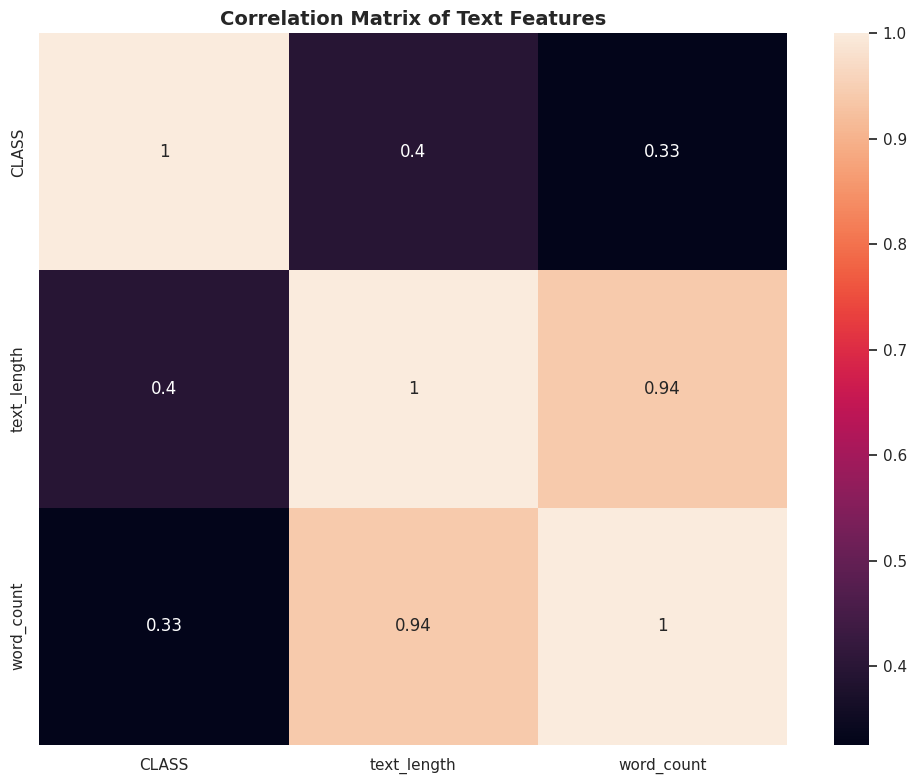

In [24]:
# Correlation matrix for text features
correlation_matrix = train_df[['CLASS', 'text_length', 'word_count']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True)

plt.title('Correlation Matrix of Text Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## Summary


In [25]:
print('1. Full interim data quality:')
print(f'   - Interim rows loaded: {len(interim_df)}')
print(f'   - Malformed rows removed before splitting: {malformed_mask.sum()}')
print(f'   - Rows checked after malformed-row filter: {len(quality_df)}')
print(f'   - Exact duplicate comments: {exact_content_duplicates}')
print()

print('2. Train-only dataset used for modeling EDA:')
print(f'   - Train comments: {len(train_df)}')
print(f'   - Spam: {(train_df["CLASS"] == 1).sum()} ({(train_df["CLASS"] == 1).sum() / len(train_df) * 100:.1f}%)')
print(f'   - Ham: {(train_df["CLASS"] == 0).sum()} ({(train_df["CLASS"] == 0).sum() / len(train_df) * 100:.1f}%)')
print(f'   - Missing values in original columns: {train_df[train_original_columns].isnull().sum().sum()}')
print(f'   - Duplicate rows: {train_df.duplicated().sum()}')
print(f'   - Duplicate content: {train_df["CONTENT"].duplicated().sum()}')
print(f'   - Missing dates: {train_df["DATE"].isna().sum()} ({(train_df["DATE"].isna().sum()/len(train_df))*100:.1f}%)')
print()

print('3. Train-only text characteristics:')
print(f'   - Average text length (Spam): {train_df[train_df["CLASS"] == 1]["text_length"].mean():.1f} chars')
print(f'   - Average text length (Ham): {train_df[train_df["CLASS"] == 0]["text_length"].mean():.1f} chars')
print(f'   - Average word count (Spam): {train_df[train_df["CLASS"] == 1]["word_count"].mean():.1f} words')
print(f'   - Average word count (Ham): {train_df[train_df["CLASS"] == 0]["word_count"].mean():.1f} words')
print()

print('4. Train-only temporal and author information:')
print(f'   - Date range: {train_df["DATE"].min().date()} to {train_df["DATE"].max().date()}')
print(f'   - Total unique authors: {train_df["AUTHOR"].nunique()}')
print()

print('5. Train-only feature correlations with CLASS:')
correlations = (
    train_df[['CLASS', 'text_length', 'word_count']]
    .corr()['CLASS']
    .sort_values(ascending=False)[1:]
)
for feature, corr in correlations.items():
    print(f'   - {feature}: {corr:.3f}')


1. Full interim data quality:
   - Interim rows loaded: 1956
   - Malformed rows removed before splitting: 1
   - Rows checked after malformed-row filter: 1955
   - Exact duplicate comments: 196

2. Train-only dataset used for modeling EDA:
   - Train comments: 1055
   - Spam: 504 (47.8%)
   - Ham: 551 (52.2%)
   - Missing values in original columns: 119
   - Duplicate rows: 0
   - Duplicate content: 0
   - Missing dates: 119 (11.3%)

3. Train-only text characteristics:
   - Average text length (Spam): 143.1 chars
   - Average text length (Ham): 50.1 chars
   - Average word count (Spam): 22.8 words
   - Average word count (Ham): 9.3 words

4. Train-only temporal and author information:
   - Date range: 2013-07-12 to 2015-06-05
   - Total unique authors: 1013

5. Train-only feature correlations with CLASS:
   - text_length: 0.395
   - word_count: 0.325
